<h1 align="center"> Linear Regression </h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Phần II: Mô hình hồi quy tuyến tính

#### Bài 1: Xây dựng mô hình hồi quy đơn biến

In [2]:
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

n = len(X)

(a) Tính toán các tham số w0 (bias) và w1 (weight) của mô hình yˆ = w0 + w1 · x bằng
phương pháp bình phương tối thiểu (Ordinary Least Squares - OLS):

In [3]:
x_mean = np.mean(X)
y_mean = np.mean(y)

In [4]:
print("Gia tri trung binh cua x :",x_mean)
print("Gia tri trung binh cua y :",y_mean)

Gia tri trung binh cua x : 3.0
Gia tri trung binh cua y : 4.0


(b) Viết phương trình đường hồi quy đơn biến.

In [5]:
numerator = np.sum((X - x_mean) * (y - y_mean))
denominator = np.sum((X - x_mean) ** 2)

w1 = numerator / denominator
w0 = y_mean - w1 * x_mean

print("w1 =", w1)
print("w0 =", w0)

w1 = 0.6
w0 = 2.2


In [6]:
print(f"Phương trình hồi quy: y_hat = {w0:.2f} + {w1:.2f}x")

Phương trình hồi quy: y_hat = 2.20 + 0.60x


(c) Dự đoán điểm thi khi học 6 giờ.

In [7]:
x_new = 6
y_pred_6 = w0 + w1 * x_new
print("Dự đoán điểm khi học 6 giờ:", y_pred_6)

Dự đoán điểm khi học 6 giờ: 5.8


(d) Tính Mean Squared Error (MSE) và R-squared (R2) của mô hình trên tập dữ liệu này.

In [8]:
y_hat = w0 + w1 * X

In [9]:
mse = np.mean((y - y_hat) ** 2)
print("MSE =", mse)

MSE = 0.47999999999999987


In [10]:

ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - y_mean) ** 2)
r2 = 1 - ss_res / ss_tot
print("R^2 =", r2)

R^2 = 0.6000000000000001


## Bài 2: Xây dựng mô hình hồi quy đa biến

(a) Chuẩn bị dữ liệu: Xây dựng ma trận thiết kế X và vector mục tiêu y, gồm:

In [11]:
X = np.array([
    [1, 1000, 2],
    [1, 1500, 3],
    [1, 2000, 4],
    [1, 1200, 2],
    [1, 1800, 3]
])

y = np.array([200, 300, 400, 220, 350])

In [12]:
print(X)

[[   1 1000    2]
 [   1 1500    3]
 [   1 2000    4]
 [   1 1200    2]
 [   1 1800    3]]


In [13]:
print(y)

[200 300 400 220 350]


(b) Tính toán các tham số w = (w0, w1, w2)^T bằng công thức Normal Equation:

In [14]:
XT = X.T
w = np.linalg.inv(XT @ X) @ XT @ y

In [15]:
w0, w1, w2 = w
print("w0 =", w0)
print("w1 =", w1)
print("w2 =", w2)

w0 = -10.841121495333148
w1 = 0.15420560747663958
w2 = 26.261682242990307


(d) Dự đoán giá nhà có diện tích 1600 m2 và 3 phòng ngủ.

In [16]:
x_new = np.array([1, 1600, 3])
y_pred = x_new @ w
print("Dự đoán giá nhà:", y_pred)

Dự đoán giá nhà: 314.67289719626115


(e) Tính MSE và R^2 của mô hình trên tập dữ liệu này.

In [17]:
y_hat = X @ w

In [18]:
mse = np.mean((y - y_hat) ** 2)
print("MSE =", mse)

MSE = 17.943925233644784


In [19]:
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot
print("R^2 =", r2)

R^2 = 0.9968760575846719


### Bài 3: Dự đoán doanh số bán hàng dựa trên chi phí quảng cáo

#### Yêu cầu 1: Chuẩn bị và khảo sát dữ liệu

- Tập dữ liệu có bao nhiêu dòng và bao nhiêu cột?

In [20]:
df = pd.read_csv("advertising.csv")

print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [21]:
print(df.shape)

(200, 4)


- Các trường dữ liệu cho biết những thông tin gì?

In [22]:
# TV, Radio, Newspaper → biến độc lập (features X)
# Sales → biến mục tiêu (target y)

- Tập dữ liệu có tồn tại các giá trị thiếu (NaN hay Null) không?

In [23]:
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


- Mối quan hệ giữa các đặc trưng với biến mục tiêu như thế nào? Hãy sử dụng
biểu đồ scatter plot để trực quan hóa mối quan hệ này.

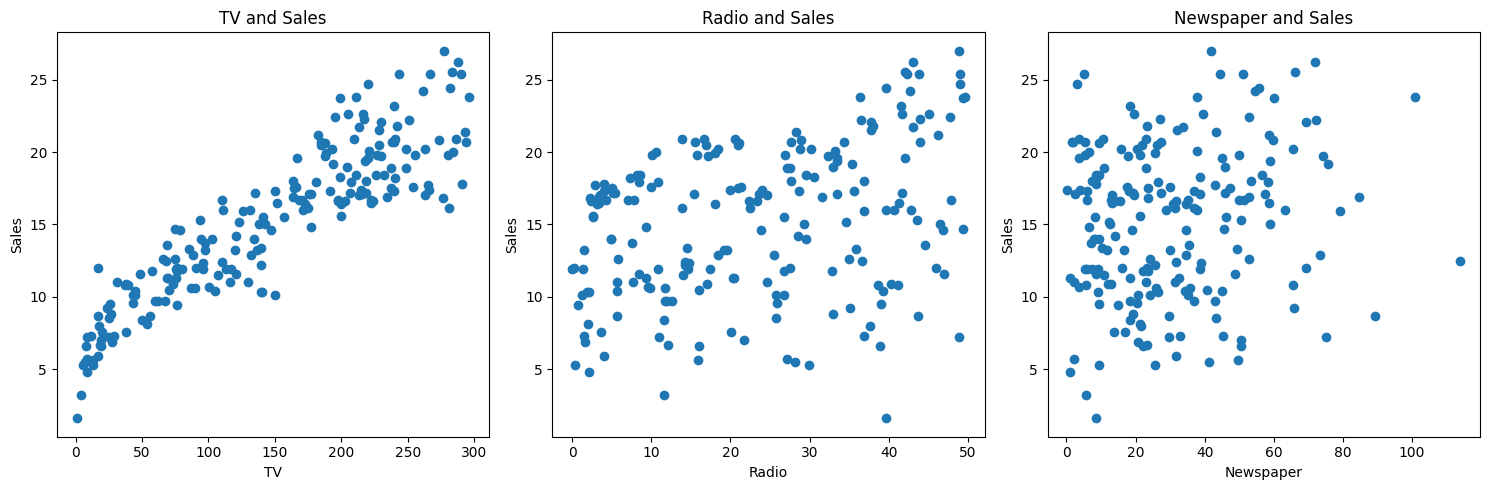

In [24]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV and Sales")

plt.subplot(1, 3, 2)
plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.title("Radio and Sales")

plt.subplot(1, 3, 3)
plt.scatter(df["Newspaper"], df["Sales"])
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.title("Newspaper and Sales")

plt.tight_layout()
plt.show()

- Nhận xét sơ bộ về phân phối của các đặc trưng và biến mục tiêu.

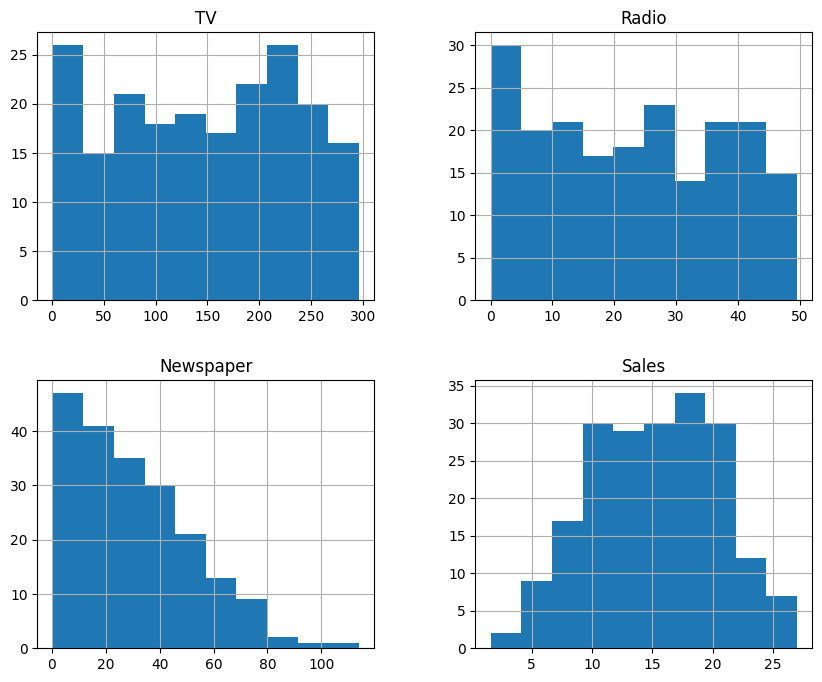

In [25]:
df.hist(figsize=(10,8))
plt.show()

#### Yêu cầu 2: Tiền xử lý dữ liệu

- Kiểm tra và xử lý các giá trị thiếu (nếu có).

In [26]:
null = df.isnull().sum()
print(null)

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [27]:
df = df.dropna()
print(df)

        TV  Radio  Newspaper  Sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3   12.0
3    151.5   41.3       58.5   16.5
4    180.8   10.8       58.4   17.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4

[200 rows x 4 columns]


In [28]:
df = df.fillna(df.mean())
print(df)

        TV  Radio  Newspaper  Sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3   12.0
3    151.5   41.3       58.5   16.5
4    180.8   10.8       58.4   17.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4

[200 rows x 4 columns]


- Trích xuất đặc trưng TV làm biến đầu vào (X) và Sales làm biến mục tiêu (y).

In [29]:
X = df["TV"]
y = df["Sales"]

- Chia tập dữ liệu thành tập huấn luyện (X_train, y_train) và tập kiểm tra (X_test,
y_test) với tỷ lệ 80:20.

In [30]:
#! pip install scikit-learn

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, random_state=42)
print(X_train.shape, X_test.shape)

(180,) (20,)


- Chuẩn hóa các đặc trưng sử dụng một trong hai phương pháp sau:

In [33]:
# Min - Max Scaling :
X_train_min = X_train.min()
X_train_max = X_train.max()

X_train_scaled = (X_train - X_train_min) / (X_train_max - X_train_min)
X_test_scaled = (X_test - X_train_min) / (X_train_max - X_train_min)

print(X_train_scaled)
print(X_test_scaled)

124    0.773757
16     0.226919
148    0.126141
93     0.846128
65     0.230977
         ...   
106    0.082178
14     0.687859
92     0.733852
179    0.557660
102    0.945215
Name: TV, Length: 180, dtype: float64
95     0.549882
15     0.658438
30     0.988164
158    0.037200
128    0.742645
115    0.251606
69     0.730808
170    0.166723
174    0.749746
45     0.589787
66     0.104160
182    0.187690
165    0.790666
78     0.015894
186    0.469395
177    0.573216
56     0.022320
152    0.665878
82     0.252283
68     0.800473
Name: TV, dtype: float64


In [34]:
# Standardzation :

X_tb = X_train.mean()
X_std = X_train.std()

X_train1_scaled = (X_train - X_tb) / X_std
X_test1_scaled = (X_test - X_tb) / X_std

print(X_train1_scaled)
print(X_test1_scaled)

124    0.954065
16    -0.937635
148   -1.286260
93     1.204420
65    -0.923596
         ...   
106   -1.438344
14     0.656915
92     0.816019
179    0.206510
102    1.547195
Name: TV, Length: 180, dtype: float64
95     0.179603
15     0.555135
30     1.695770
158   -1.593939
128    0.846436
115   -0.852233
69     0.805490
170   -1.145874
174    0.871003
45     0.317649
66    -1.362302
182   -1.073341
165    1.012559
78    -1.667641
186   -0.098829
177    0.260325
56    -1.645413
152    0.580873
82    -0.849893
68     1.046486
Name: TV, dtype: float64


In [35]:
print("Mean sau scale:", X_train1_scaled.mean())
print("Std sau scale:", X_train1_scaled.std())

Mean sau scale: -1.0855514018557086e-16
Std sau scale: 0.9999999999999999


#### Yêu cầu 3: Xây dựng và huấn luyện mô hình hồi quy tuyến tính đơn biến

In [52]:
X_train_np = X_train1_scaled.values.flatten()
y_train_np = y_train.values

In [53]:
X_test_scaled = X_test1_scaled.values.flatten()
y_test_np = y_test.values

In [37]:
def predict(X, w0, w1):
    return w0 + w1 * X

In [38]:
def loss_function(y_true, y_pred):
    n = len(y_true)
    return np.sum((y_true - y_pred) ** 2)/n

In [39]:
def gradient(X, y, w0, w1):
    n = len(y)
    y_pred = w0 + w1 * X

    dw0 = (-2/n) * np.sum(y - y_pred)
    dw1 = (-2/n) * np.sum((y - y_pred) * X)

    return dw0, dw1


In [40]:
def fit(X, y, learning_rate = 0.01, epochs = 1000):
    learning_rate = learning_rate
    epochs = epochs
    losses = []
    w0 = 0.0
    w1 = 0.0

    for epoch in range(epochs):
        y_pred = predict(X, w0, w1)
        dw0, dw1 = gradient(X, y, w0, w1)
        w0 -= learning_rate * dw0
        w1 -= learning_rate * dw1
        y_pred_new = predict(X, w0, w1)
        loss = loss_function(y, y_pred_new)
        losses.append(loss)
        print(f'Epoch : {epoch}, Loss : {loss}  ')
    return w0, w1, losses

In [41]:
def plot_learning_curve(losess):
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(losess)), losess, label = 'Training loss(MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid()
    plt.show()

In [42]:
w0, w1, losses = fit(X_train_np, y_train_np, 0.01, 1000)

Epoch : 0, Loss : 248.2541874695186  
Epoch : 1, Loss : 238.629849617192  
Epoch : 2, Loss : 229.3864535726586  
Epoch : 3, Loss : 220.5089212067561  
Epoch : 4, Loss : 211.98277120200743  
Epoch : 5, Loss : 203.7940954299927  
Epoch : 6, Loss : 195.92953626373958  
Epoch : 7, Loss : 188.37626478812282  
Epoch : 8, Loss : 181.12195987272764  
Epoch : 9, Loss : 174.15478807303973  
Epoch : 10, Loss : 167.46338432717582  
Epoch : 11, Loss : 161.0368334166652  
Epoch : 12, Loss : 154.86465216104042  
Epoch : 13, Loss : 148.936772317192  
Epoch : 14, Loss : 143.24352415559102  
Epoch : 15, Loss : 137.7756206865886  
Epoch : 16, Loss : 132.524142511061  
Epoch : 17, Loss : 127.48052327068754  
Epoch : 18, Loss : 122.6365356741278  
Epoch : 19, Loss : 117.98427807630195  
Epoch : 20, Loss : 113.51616158888254  
Epoch : 21, Loss : 109.22489770097123  
Epoch : 22, Loss : 105.1034863897664  
Epoch : 23, Loss : 101.14520470182724  
Epoch : 24, Loss : 97.34359578630762  
Epoch : 25, Loss : 93.692

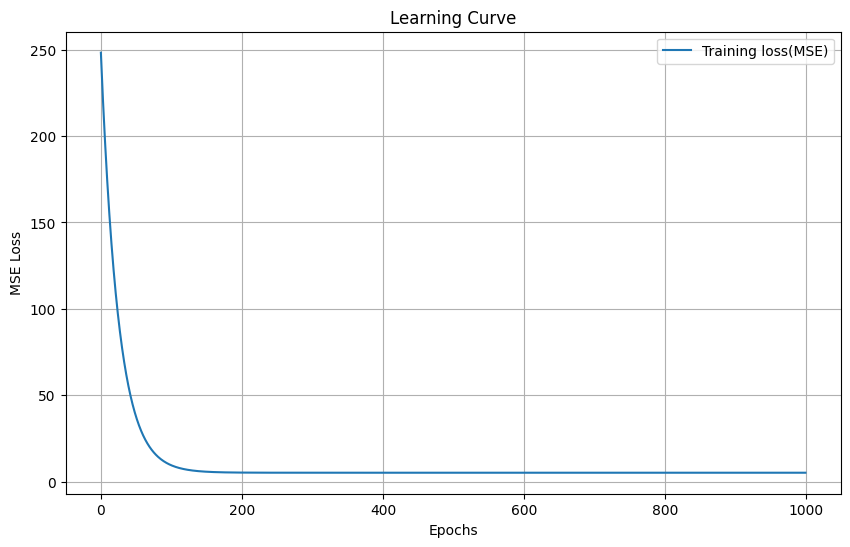

In [43]:
plot_learning_curve(losses)

In [54]:
def evaluate(y_true, y_pred):
    n = len(y_true)
    
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    ssr = np.sum((y_true - y_pred) ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    r_squared = 1 - (ssr/sst)

    return mae, mse, rmse, r_squared

In [56]:
y_pred = predict(X_test_scaled, w0, w1)

mae, mse, rmse, r_squared = evaluate(y_test_np, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r_squared)

MAE : 2.0379553524213234
MSE : 6.302018978342165
RMSE: 2.5103822374973426
R2  : 0.8071768729720384


Yêu cầu 5: Điều chỉnh siêu tham số và thử nghiệm với các đặc trưng khác

Yêu cầu 6: Mở rộng số lượng đặc trưng đầu vào

In [ ]:
def predict1(X, w, b):
    return X @ w + b

In [ ]:
def gradient1(X, y, w, b):
    y_pred1 = X @ w + b
    
    dw = (-2/n) * (X.T @ (y - y_pred1))
    db = (-2/n) * (np.sum(y - y_pred1))

    return dw, db

In [ ]:
def fit1(X, y, learning_rate = 0.01, epochs = 1000):
    n_sam, n_fea = X.shape
    w = np.zeros(n_fea)
    b = 0.0

    losses = []

    for epoch in range(epochs):
        y_pred1 = predict1(X, w, b)

        loss = np.mean((y - y_pred1) ** 2)
        losses.append(loss)

        dw, db = gradient1(X, y, w, b)

        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b, losses

In [ ]:
X1 = df[['TV', 'Radio', 'Newspaper']]
y1 = df[['Sales']].values.flatten()

In [92]:
w, b, losses = fit(X_train1_scaled, y_train)
y_pred = predict(X_test1_scaled, w, b)

Epoch : 0, Loss : 248.2541874695186  
Epoch : 1, Loss : 238.629849617192  
Epoch : 2, Loss : 229.3864535726586  
Epoch : 3, Loss : 220.5089212067561  
Epoch : 4, Loss : 211.98277120200743  
Epoch : 5, Loss : 203.7940954299927  
Epoch : 6, Loss : 195.92953626373958  
Epoch : 7, Loss : 188.37626478812282  
Epoch : 8, Loss : 181.12195987272764  
Epoch : 9, Loss : 174.15478807303973  
Epoch : 10, Loss : 167.46338432717582  
Epoch : 11, Loss : 161.0368334166652  
Epoch : 12, Loss : 154.86465216104042  
Epoch : 13, Loss : 148.936772317192  
Epoch : 14, Loss : 143.24352415559102  
Epoch : 15, Loss : 137.7756206865886  
Epoch : 16, Loss : 132.524142511061  
Epoch : 17, Loss : 127.48052327068754  
Epoch : 18, Loss : 122.6365356741278  
Epoch : 19, Loss : 117.98427807630195  
Epoch : 20, Loss : 113.51616158888254  
Epoch : 21, Loss : 109.22489770097123  
Epoch : 22, Loss : 105.1034863897664  
Epoch : 23, Loss : 101.14520470182724  
Epoch : 24, Loss : 97.34359578630762  
Epoch : 25, Loss : 93.692

In [97]:
X_test = df[["TV", "Radio", "Newspaper"]]

In [101]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None
        self.losses = []

    def predict(self, X):
        return X @ self.w + self.b

    def loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def gradient(self, X, y):
        n = len(y)
        y_pred = self.predict(X)
        error = y - y_pred
        
        dw = (-2/n) * (X.T @ error)
        db = (-2/n) * np.sum(error)
        
        return dw, db

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.losses = []
        
        for epoch in range(self.epochs):
            y_pred = self.predict(X)
            
            loss = self.loss(y, y_pred)
            self.losses.append(loss)
            
            dw, db = self.gradient(X, y)
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
        return self

    def evaluate(self, y_true, y_pred):
        mae = np.mean(np.abs(y_true - y_pred))
        mse = np.mean((y_true - y_pred) ** 2)
        rmse = np.sqrt(mse)
        
        ssr = np.sum((y_true - y_pred) ** 2)
        sst = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - ssr/sst
        
        return mae, mse, rmse, r2

In [103]:
import pandas as pd
import numpy as np

# ===== 1. Đọc dữ liệu =====
df = pd.read_csv("advertising.csv")

print(df.head())
print(df.info())

# ===== 2. Tách biến =====
X = df[['TV', 'Radio', 'Newspaper']].values
y = df['Sales'].values

# ===== 3. Chuẩn hóa (RẤT NÊN dùng) =====
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ===== 4. Train =====
model = LinearRegression(learning_rate=0.01, epochs=5000)
model.fit(X, y)

# ===== 5. Đánh giá =====
mae, mse, rmse, r2 = model.evaluate(X, y)

print("\n===== KẾT QUẢ =====")
print("w:", model.w)
print("b:", model.b)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


ValueError: operands could not be broadcast together with shapes (200,3) (200,) 

In [95]:
print("Train shape:", X.shape)
print("Test shape:", X_test.shape)
print("w shape:", model.w.shape)

Train shape: (200, 3)
Test shape: (20,)
w shape: (3,)
